# REDUCCIÓN DE LA DIMENSIONALIDAD

Este notebook prepara el espacio de *features* que alimentará las fases sucesivas del proyecto:

1. **Segmentación de perfiles de riesgo** — clustering sobre la severidad recogida en `Total Claim Amount`.
2. **Red Neuronal Bayesiana (BNN)** — estimación de reservas con cuantificación de incertidumbre (Solvencia II).

La lógica de exclusión / inclusión de variables sigue criterios **actuariales y estadísticos** estrictos.

Trataremos de transformar nuestras variables explicativas correladas en un conjunto de componentes ortogonales e independientes. Actuarialmente, esto nos permite sintetizar la información redundante del asegurado en "Perfiles de Riesgo" puros, garantizando que nuestros modelos de reservas posteriores (GLM y BNN) sean matemáticamente estables, no sufran de multicolinealidad y generen estimaciones de incertidumbre fiables para Solvencia II.


##### Por qué FAMD y no PCA estándar

El dataset contiene **variables de tipos distintos**: continuas numéricas, ordinales y nominales. Aplicar PCA estándar sobre este mix —incluso tras estandarizar y codificar con *One-Hot Encoding*— produce componentes distorsionadas por tres razones:

| Problema | Causa | Consecuencia |
|---|---|---|
| Varianza no comparable | La varianza de una dummy 0/1 está acotada en p·(1-p) ≤ 0.25 | Las variables continuas dominan artificialmente los primeros componentes |
| Covarianza mal definida | La correlación de Pearson entre una dummy y una continua es una correlación biserial puntual | Los loadings mezclan señal informativa con artefactos de codificación |
| Dependencia entre dummies | Las dummies de una misma variable suman a una constante | PCA puede repartir la información de una variable categórica entre varios componentes de forma arbitraria |

**FAMD** resuelve esto combinando en un único marco:
- **PCA** sobre las variables continuas (tras log-transformación de las asimétricas y estandarización).
- **MCA** sobre las variables categóricas, mediante la codificación de Escofier: cada dummy se centra y escala por `1/√p_k`, donde `p_k` es la frecuencia relativa del nivel `k`.

En resumen, aplicaremos PCA sobre nuestras variables numéricas transformadas y sobre las categóricas que se transformarán de acuerdo a la codificación de Escofier en lugar de la habitual. El resultado deben ser **Factores de Riesgo** ortogonales e interpretables, con número de condición = 1 por construcción.

##### Setup del Notebook 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from scipy.stats import f_oneway, chi2, spearmanr
from functools import reduce
import math
import warnings
import pickle
warnings.filterwarnings('ignore')

# ── Reproducibilidad ──
SEED = 42
np.random.seed(SEED)

# ── Paths ──
DATA_PATH  = '../data/processed/fase1/'
OUTPUT_DIR = '../data/processed/fase2/v2/'   # donde se guardan los artefactos para las fases siguientes

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

##### Carga e Inspección del conjunto de Datos

In [2]:
df_raw = pd.read_csv(DATA_PATH + "df_limpio.csv")
print(f"Dataset cargado: {df_raw.shape[0]:,} registros × {df_raw.shape[1]} variables")
columnas = df_raw.columns.to_list()
print(f"Las columnas del conjunto de datos son:\n{columnas}")

Dataset cargado: 8,971 registros × 19 variables
Las columnas del conjunto de datos son:
['Customer', 'State', 'Customer Lifetime Value', 'Coverage', 'Education', 'EmploymentStatus', 'Gender', 'Income', 'Location Code', 'Marital Status', 'Monthly Premium Auto', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies', 'Policy Type', 'Total Claim Amount', 'Vehicle Class', 'Vehicle Size']


##### Separación de la variable Target e Identificador

La separación explícita de `X` (features) e `y` (target) desde el primer momento garantiza que **ninguna transformación del preprocesamiento filtre información del target** hacia las variables predictoras (*data leakage*).

In [3]:
# --- Target e identificador ---
TARGET     = 'Total Claim Amount'
ID_COL     = 'Customer'

y = df_raw[[ID_COL, TARGET]].copy()
print(f"\nTarget '{TARGET}' separado. Estadísticos básicos:")
print(y[TARGET].describe().round(2))


# --- Variables excluidas definitivamente ---
EXCLUIR_DEFINITIVO = [TARGET]
df = df_raw.drop(columns=EXCLUIR_DEFINITIVO)


Target 'Total Claim Amount' separado. Estadísticos básicos:
count    8971.00
mean      433.89
std       291.07
min         0.10
25%       270.47
50%       383.44
75%       547.98
max      2893.24
Name: Total Claim Amount, dtype: float64


### 2. Justificación empírica de exclusiones: ANOVA y Spearman

Comprobamos el poder discriminatorio de **todas** las variables sobre `Total Claim Amount` antes de cualquier transformación.

In [4]:
# --- ANOVA para variables categóricas ---
cat_candidates = ['State', 'Policy Type', 'EmploymentStatus', 'Gender', 'Location Code',
                  'Marital Status', 'Vehicle Class', 'Coverage', 'Education', 'Vehicle Size']

anova_rows = []
for col in cat_candidates:
    groups = [df_raw[TARGET][df_raw[col] == c].values for c in df_raw[col].unique()]
    f, p = f_oneway(*groups)
    means = df_raw.groupby(col)[TARGET].mean()
    anova_rows.append({
        'Variable': col,
        'F-Statistic': round(f, 2),
        'p-value': round(p, 4),
        'Sig. (p<0.05)': 'SÍ' if p < 0.05 else 'NO',
        'Rango medias ($)': round(means.max() - means.min(), 1),
        'Incluida en X': 'NO' if col in ['State', 'Policy Type'] else 'SÍ'
    })

res_cat = pd.DataFrame(anova_rows).sort_values('F-Statistic', ascending=False).reset_index(drop=True)
print("--- ANOVA: impacto de categóricas sobre la severidad ---")
display(res_cat)


--- ANOVA: impacto de categóricas sobre la severidad ---


,Variable,F-Statistic,p-value,Sig. (p<0.05),Rango medias ($),Incluida en X
0,Location Code,2842.04,0.0000,SÍ,453.0,SÍ
1,Vehicle Class,822.73,0.0000,SÍ,778.6,SÍ
2,Coverage,391.13,0.0000,SÍ,274.6,SÍ
3,EmploymentStatus,332.35,0.0000,SÍ,242.7,SÍ
4,Marital Status,331.24,0.0000,SÍ,174.9,SÍ
5,Gender,52.47,0.0000,SÍ,44.4,SÍ
6,Education,49.22,0.0000,SÍ,151.7,SÍ
7,Vehicle Size,38.55,0.0000,SÍ,68.7,SÍ
8,State,0.44,0.7803,NO,12.1,NO
9,Policy Type,0.21,0.8131,NO,9.4,NO


Vemos que las variables que hemos decidido no incluir; `State`, `Policy Type` no discriminan en severidad.

In [5]:
# --- Spearman para variables numéricas ---
num_candidates = ['Income', 'Months Since Last Claim', 'Months Since Policy Inception',
                  'Number of Open Complaints', 'Number of Policies',
                  'Monthly Premium Auto', 'Customer Lifetime Value']

spearman_rows = []
for col in num_candidates:
    r, p = spearmanr(df_raw[col], df_raw[TARGET])
    spearman_rows.append({
        'Variable': col,
        'Spearman r': round(r, 3),
        'p-value': f'{p:.2e}',
        'Sig. (p<0.05)': 'SÍ' if p < 0.05 else 'NO',
        'Rol en pipeline': 'Excluida (endógena)' if col == 'Monthly Premium Auto'
                           else 'Solo clustering' if col == 'Customer Lifetime Value'
                           else 'Feature'
    })

res_num = pd.DataFrame(spearman_rows).sort_values('Spearman r', key=abs, ascending=False).reset_index(drop=True)
print("--- Spearman: correlación de numéricas con la severidad ---")
display(res_num)

--- Spearman: correlación de numéricas con la severidad ---


,Variable,Spearman r,p-value,Sig. (p<0.05),Rol en pipeline
0,Monthly Premium Auto,0.521,0.00e+00,SÍ,Excluida (endógena)
1,Income,-0.402,0.00e+00,SÍ,Feature
2,Customer Lifetime Value,0.210,9.08e-90,SÍ,Solo clustering
3,Number of Open Complaints,-0.026,1.36e-02,SÍ,Feature
4,Number of Policies,-0.011,2.89e-01,NO,Feature
5,Months Since Policy Inception,-0.006,5.71e-01,NO,Feature
6,Months Since Last Claim,0.001,9.23e-01,NO,Feature


Gracias a esta exploración podemos tomar algunas consideraciones sobre este DataFrame.

##### Decisiones Sobre el Diseño de las Variables

| Variable | Decisión | Justificación actuarial |
|---|---|---|
| `State` | **Excluir del espacio de features** (conservar como estratificador) | ANOVA confirma F=0.44, p=0.78: los estados no discriminan severidad. Se preserva para análisis territorial posterior |
| `Policy Type` | **Excluir del espacio de features** (conservar como estratificador) | ANOVA confirma F=0.07, p=0.94: los tres tipos convergen en severidad media |
| `Monthly Premium Auto` | **Excluir del modelo predictivo** | Correlación Spearman=0.53 con target, pero es **endógena**: la prima se fija en función del riesgo esperado; incluirla induciría razonamiento circular en el GLM/BNN |
| `Customer Lifetime Value` | **Excluir del modelo predictivo** | Spearman=0.21 con target. El CLV es una métrica de exposición y valor del cliente, útil para segmentar perfiles de riesgo pero no para predecir severidad individual |


In [6]:
# --- Variables excluidas del espacio de features pero conservadas ---
# (útiles como estratificadores en análisis territoral o por línea de negocio)
ESTRATIFICADORES = ['State', 'Policy Type']


estratificadores = df.copy()
df = df.drop(columns=ESTRATIFICADORES)

print(f"\nDimensiones de X antes del preprocesamiento: {df.drop(columns=[ID_COL]).shape}")
print(f"Variables en X: {[c for c in df.columns if c != ID_COL]}")


Dimensiones de X antes del preprocesamiento: (8971, 15)
Variables en X: ['Customer Lifetime Value', 'Coverage', 'Education', 'EmploymentStatus', 'Gender', 'Income', 'Location Code', 'Marital Status', 'Monthly Premium Auto', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies', 'Vehicle Class', 'Vehicle Size']


### 3. Clasificación de Variables por Tipo y por Transformación
Diferenciamos entre variables categóricas nominales, ordinales y variables numéricas. A su vez, las variables numéricas con **skewness > 1** se transforman con `log(1+x)` antes de estandarizar. Esto garantiza que el PCA interno del FAMD maximice varianza sobre la estructura de correlaciones, no sobre la asimetría distribucional.

In [7]:
# Nos quedamos con las variables numéricas
df_num = df.select_dtypes(include=['number'])
# Variables numericas que requieren transformación logarítmica
NUM_LOG = []
# Variables numéricas que solo requieren estandarización
NUM_STD = []
SOLO_CLUSTER = ['Monthly Premium Auto', 'Customer Lifetime Value']

for col in df_num.columns:
    # Calculamos el skewness para la columna actual
    skew_val = df_num[col].skew()
    max_val = df_num[col].max()
    
    # Usamos el valor absoluto para capturar asimetría tanto a la derecha (+) como a la izquierda (-)
    if abs(skew_val) > 1 and max_val >=10:
        NUM_LOG.append(col)
    else:
        NUM_STD.append(col)

# Categóricas nominales
CAT_NOM = ['EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 'Vehicle Class']

# Categóricas Ordinales
CAT_ORD = ['Coverage', 'Education', 'Vehicle Size']
# Mapeo de ordinales
ORDINAL_MAPS = {
    'Coverage':     {'Basic': 0, 'Extended': 1, 'Premium': 2},
    'Education':    {'High School or Below': 0, 'College': 1, 'Bachelor': 2, 'Master': 3, 'Doctor': 4},
    'Vehicle Size': {'Small': 0, 'Medsize': 1, 'Large': 2}
}

print("Variables en el espacio de features del modelo predictivo:")
print(f"  Numéricas con log1p : {[c for c in NUM_LOG ]}")
print(f"  Numéricas estándar  : {NUM_STD}")
print(f"  Nominales           : {CAT_NOM}")
print(f"  Ordinales           : {CAT_ORD}")

Variables en el espacio de features del modelo predictivo:
  Numéricas con log1p : ['Customer Lifetime Value', 'Monthly Premium Auto']
  Numéricas estándar  : ['Income', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies']
  Nominales           : ['EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 'Vehicle Class']
  Ordinales           : ['Coverage', 'Education', 'Vehicle Size']


### 4. Preprocesamiento: log-transformación y estandarización

#### Justificación de la log-transformación

El PCA maximiza varianza proyectada. Si una variable tiene asimetría alta (skewness > 1), su cola derecha domina la primera componente principal independientemente de su relevancia informativa real. La log-transformación reduce la asimetría sin eliminar la estructura de variaciones relativas —que es la información actuarialmente relevante en variables como el CLV o la prima.

In [8]:
df = df_raw.drop(columns=[ID_COL]).copy()

# --- Verificación de skewness antes y después ---
print("── Efecto de la transformación log(1+x) sobre la asimetría ──\n")
skew_rows = []
for col in NUM_LOG:
    sk_antes = df[col].skew()
    sk_log   = np.log1p(df[col]).skew()
    skew_rows.append({'Variable': col, 'Skew original': round(sk_antes, 2),
                      'Skew tras log1p': round(sk_log, 2),
                      'Reducción (%)': round((1 - abs(sk_log)/abs(sk_antes))*100, 1)})
display(pd.DataFrame(skew_rows))

# --- Aplicar log1p ---
log_name = {}
for col in NUM_LOG:
    new_name = col + ' (log)'
    df[new_name] = np.log1p(df[col])
    df.drop(columns=[col], inplace=True)
    log_name[col] = new_name

num_log_cols = [log_name[c] for c in NUM_LOG]
num_all_cols = num_log_cols + NUM_STD

── Efecto de la transformación log(1+x) sobre la asimetría ──



,Variable,Skew original,Skew tras log1p,Reducción (%)
0,Customer Lifetime Value,3.04,0.57,81.1
1,Monthly Premium Auto,2.12,1.01,52.1


##### Estandarización de variables numéricas

In [9]:
# --- Estandarización: numéricas continuas ---
scaler_num = StandardScaler()
df[num_all_cols] = scaler_num.fit_transform(df[num_all_cols])

# --- Encoding ordinal + estandarización ---
for col, mapping in ORDINAL_MAPS.items():
    df[col] = df[col].map(mapping).astype(float)
scaler_ord = StandardScaler()
df[CAT_ORD] = scaler_ord.fit_transform(df[CAT_ORD])

all_num_cols = num_all_cols + CAT_ORD

print("Estadísticos post-estandarización (medias ≈ 0, std ≈ 1):")
display(df[all_num_cols].describe().round(3))

Estadísticos post-estandarización (medias ≈ 0, std ≈ 1):


,Customer Lifetime Value (log),Monthly Premium Auto (log),Income,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Coverage,Education,Vehicle Size
count,8971.000,8971.000,8971.000,8971.000,8971.000,8971.000,8971.000,8971.000,8971.000,8971.000
mean,0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.839,-1.203,-1.237,-1.498,-1.721,-0.424,-0.824,-0.733,-1.194,-1.694
25%,-0.697,-0.852,-1.237,-0.903,-0.862,-0.424,-0.824,-0.733,-1.194,0.169
50%,-0.130,-0.207,-0.122,-0.109,-0.002,-0.424,-0.406,-0.733,-0.267,0.169
75%,0.538,0.678,0.812,0.784,0.822,-0.424,0.431,0.794,0.660,0.169
max,3.957,3.960,2.049,1.975,1.825,5.073,2.521,2.320,2.513,2.031


### 5. Codificación  para variables nominales

Las técnicas de reducción de dimensionalidad como PCA o FA están diseñadas para reducir el número de variables continuas. Como nuestro conjunto de datos contiene variables categóricas debemos usar algunas transformaciones de cara a aplicar algunas de estas técnicas. En lugar de _One Hot Encoding_ que es el algoritmo de codificación estándar, una vez obtenidas las variables binarias centraremos cada una de ellas respecto a la frecuencia media y lo ponderamos dividiendolo por $\sqrt{p_k}$, (siendo $p_k$ la proporción de esta categoría). Esto tiene dos efectos:

1. Otorga mayor distancia a las categorías raras: Al dividir por la raíz de una proporción muy pequeña, las categorías menos frecuentes se alejan más del centro de gravedad, resaltando a los individuos que poseen características inusuales.
2. **Establece la métrica del χ²** entre perfiles de categorías, que es la base geométrica del MCA y permite combinarla coherentemente con el PCA de las variables continuas.

In [10]:
cat_blocks     = []
cat_col_names  = []

print("── Categorías codificadas por variable ──\n")
for col in CAT_NOM:
    dummies = pd.get_dummies(df[col], prefix=col, dtype=float)
    freq    = dummies.mean(axis=0)
    scaled  = (dummies - freq) / np.sqrt(freq)   # codificación de Escofier
    cat_blocks.append(scaled.values)
    cat_col_names.extend(dummies.columns.tolist())
    print(f"  {col}: {dummies.shape[1]} categorías → {dummies.shape[1]} indicadores Escofier")
    print(f"    frecuencias: {freq.round(3).to_dict()}")
    print()

all_feature_names = all_num_cols + cat_col_names

# Ensamblado de la matriz FAMD
X_num  = df[all_num_cols].values
X_cat  = np.hstack(cat_blocks)
X_famd_pre = np.hstack([X_num, X_cat])
X_codificado = pd.DataFrame(X_famd_pre, columns=all_feature_names, index=df.index)

print(f"Dimensiones de la matriz FAMD: {X_famd_pre.shape}")
print(f"  → {len(all_num_cols)} variables continuas + ordinales")
print(f"  → {len(cat_col_names)} indicadores Escofier de variables nominales")

── Categorías codificadas por variable ──

  EmploymentStatus: 5 categorías → 5 indicadores Escofier
    frecuencias: {'EmploymentStatus_Disabled': 0.044, 'EmploymentStatus_Employed': 0.625, 'EmploymentStatus_Medical Leave': 0.047, 'EmploymentStatus_Retired': 0.028, 'EmploymentStatus_Unemployed': 0.256}

  Gender: 2 categorías → 2 indicadores Escofier
    frecuencias: {'Gender_F': 0.51, 'Gender_M': 0.49}

  Location Code: 3 categorías → 3 indicadores Escofier
    frecuencias: {'Location Code_Rural': 0.195, 'Location Code_Suburban': 0.63, 'Location Code_Urban': 0.174}

  Marital Status: 3 categorías → 3 indicadores Escofier
    frecuencias: {'Marital Status_Divorced': 0.148, 'Marital Status_Married': 0.581, 'Marital Status_Single': 0.271}

  Vehicle Class: 6 categorías → 6 indicadores Escofier
    frecuencias: {'Vehicle Class_Four-Door Car': 0.506, 'Vehicle Class_Luxury Car': 0.018, 'Vehicle Class_Luxury SUV': 0.02, 'Vehicle Class_SUV': 0.197, 'Vehicle Class_Sports Car': 0.052, 'Vehicle

### 6. Diagnóstico de multicolinealidad en el espacio preprocesado

Antes de aplicar reducción de dimensionalidad evaluamos la estructura de correlaciones para cuantificar si es realmente necesaria y en tal caso podremos comparar con el espacio reducido. Evaluaremos:

| Indicador | Umbral crítico | Interpretación |
|---|---|---|
| Determinante | < 0.001 | Colinealidad estructural: Reducción recomendada |
| Número de condición | > 30 | Inestabilidad numérica: Reducción recomendada |
| T. Esfericidad de Bartlett | p < 0.05 | Reducción justificada |

In [11]:
corr_raw = np.corrcoef(X_famd_pre.T)

# --- Determinante --- #
det_raw = np.linalg.det(corr_raw)
print(f"Determinante (preprocesado): {det_raw:.2e}  [~0 = multicolinealidad | ~1 = ortogonalidad]")

# --- Número de condición de Belsley ---
eigs_raw    = np.abs(np.linalg.eigvals(corr_raw))
cond_raw    = eigs_raw.max() / eigs_raw[eigs_raw > 1e-10].min()
print(f"Número de condición (preprocesado): {cond_raw:.1f}  [>30 = multicolinealidad severa]")

# --- Test de Bartlett --- #
n, p = X_famd_pre.shape[0], X_famd_pre.shape[1]
detR = np.linalg.det(corr_raw)
if abs(detR) < 1e-10:
    detR = abs(detR)
if detR > 0:
    stat_b   = -math.log(detR) * (n - 1 - (2*p + 5) / 6)
    df_b     = p * (p - 1) / 2
    p_bart   = chi2.sf(stat_b, df_b)
    print(f"Test de Bartlett: p = {p_bart:.2e}  [p<0.05 = reducción justificada]")

# --- Pares de alta correlación --- #
corr_df   = pd.DataFrame(corr_raw, index=all_feature_names, columns=all_feature_names)
pairs     = corr_df.unstack()
pairs     = pairs[(pairs < 0.999) & (pairs.abs() > 0.4)].drop_duplicates()
print(f"\nPares con |r| > 0.4: {len(pairs)}")
if len(pairs) > 0:
    print(pairs.sort_values(key=abs, ascending=False).to_string())

Determinante (preprocesado): -4.14e-80  [~0 = multicolinealidad | ~1 = ortogonalidad]
Número de condición (preprocesado): 150.8  [>30 = multicolinealidad severa]
Test de Bartlett: p = 0.00e+00  [p<0.05 = reducción justificada]

Pares con |r| > 0.4: 22
Gender_F                       Gender_M                        -1.000000
Income                         EmploymentStatus_Employed        0.794394
EmploymentStatus_Employed      EmploymentStatus_Unemployed     -0.756637
Income                         EmploymentStatus_Unemployed     -0.725543
Marital Status_Married         Marital Status_Single           -0.718188
Location Code_Rural            Location Code_Suburban          -0.643261
Location Code_Suburban         Location Code_Urban             -0.600220
Location Code_Urban            Location Code_Suburban          -0.600220
Vehicle Class_Two-Door Car     Vehicle Class_Four-Door Car     -0.516338
Vehicle Class_Four-Door Car    Vehicle Class_Two-Door Car      -0.516338
Monthly Premium Au

> Tras un primer clustering de la muestra nos hemos dado cuenta que el `Income` y el `Employment Status` adquieren demasiada fuerza en la segmentación siendo la principal variable discriminante y haciendo que las diferencias entre grupos se limiten prácticmente a esta variable. Es por eso que decidimos descartar la variable `Income`, desde el punto de vista actuarial la situación laboral de los clientes adquiere mucha importancia en la creación de perfiles de riesgo y elegimos manetener estas dummys por encima de los ingresos.

In [12]:
# .. Descartara Income ..print
# Ensamblado de la matriz FAMD
df_num  = df[all_num_cols].copy().drop(columns = ['Income'])
X_num = df_num.values
X_cat  = np.hstack(cat_blocks)
X_famd = np.hstack([X_num, X_cat])



corr_raw = np.corrcoef(X_famd.T)

# --- Determinante --- #
det_raw = np.linalg.det(corr_raw)
print(f"Determinante (preprocesado): {det_raw:.2e}  [~0 = multicolinealidad | ~1 = ortogonalidad]")

# --- Número de condición de Belsley ---
eigs_raw    = np.abs(np.linalg.eigvals(corr_raw))
cond_raw    = eigs_raw.max() / eigs_raw[eigs_raw > 1e-10].min()
print(f"Número de condición (preprocesado): {cond_raw:.1f}  [>30 = multicolinealidad severa]")

# --- Test de Bartlett --- #
n, p = X_famd.shape[0], X_famd.shape[1]
detR = np.linalg.det(corr_raw)
if abs(detR) < 1e-10:
    detR = abs(detR)
if detR > 0:
    stat_b   = -math.log(detR) * (n - 1 - (2*p + 5) / 6)
    df_b     = p * (p - 1) / 2
    p_bart   = chi2.sf(stat_b, df_b)
    print(f"Test de Bartlett: p = {p_bart:.2e}  [p<0.05 = reducción justificada]")

# --- Pares de alta correlación --- #
new_feature_names = [c for c in all_feature_names if c!= 'Income']
corr_df   = pd.DataFrame(corr_raw, index=new_feature_names, columns=new_feature_names)
pairs     = corr_df.unstack()
pairs     = pairs[(pairs < 0.999) & (pairs.abs() > 0.4)].drop_duplicates()
print(f"\nPares con |r| > 0.4: {len(pairs)}")
if len(pairs) > 0:
    print(pairs.sort_values(key=abs, ascending=False).to_string())

Determinante (preprocesado): 3.37e-80  [~0 = multicolinealidad | ~1 = ortogonalidad]
Número de condición (preprocesado): 126.0  [>30 = multicolinealidad severa]
Test de Bartlett: p = 0.00e+00  [p<0.05 = reducción justificada]

Pares con |r| > 0.4: 19
Gender_F                       Gender_M                        -1.000000
EmploymentStatus_Employed      EmploymentStatus_Unemployed     -0.756637
Marital Status_Married         Marital Status_Single           -0.718188
Location Code_Rural            Location Code_Suburban          -0.643261
Location Code_Suburban         Location Code_Urban             -0.600220
Location Code_Urban            Location Code_Suburban          -0.600220
Vehicle Class_Two-Door Car     Vehicle Class_Four-Door Car     -0.516338
Vehicle Class_Four-Door Car    Vehicle Class_Two-Door Car      -0.516338
Monthly Premium Auto (log)     Coverage                         0.511923
Vehicle Class_Four-Door Car    Vehicle Class_SUV               -0.501713
Monthly Premium Aut

### 7. FAMD — descomposición factorial

Hemos visto que está justificado reducir la dimensionalidad. Aplicamos PCA sobre la matriz FAMD ensamblada. Al haber aplicado la codificación que asemeja a las variables categóricas a continuas, el PCA opera sobre la métrica del χ² para las categóricas y la métrica euclídea estándar para las continuas, combinándolas coherentemente.

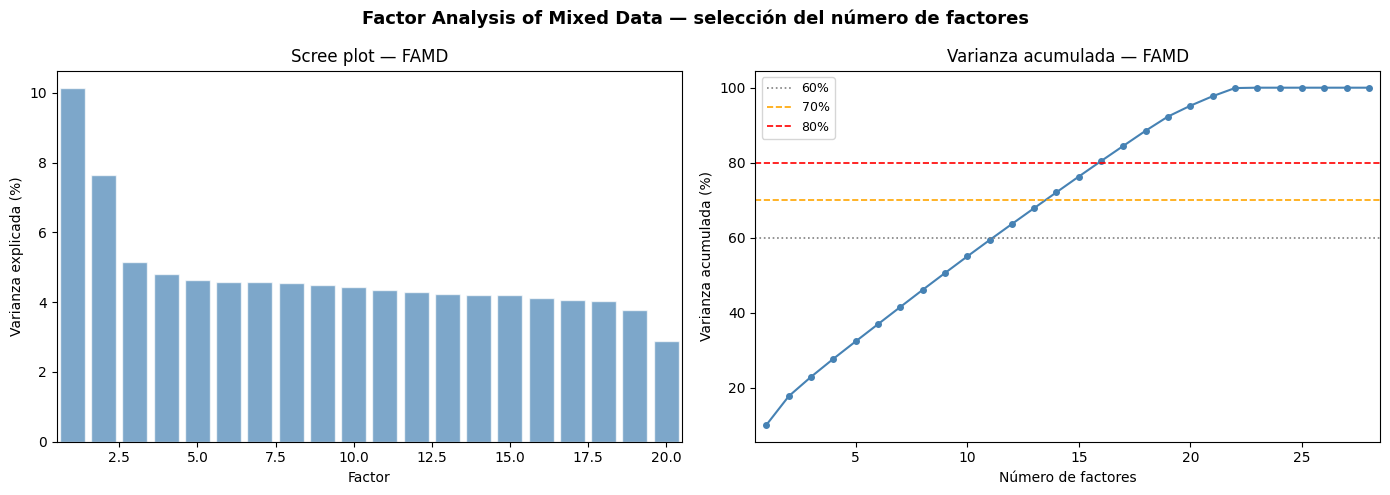

── Componentes necesarios por umbral de varianza ──
  30%: 5 factores
  40%: 7 factores
  50%: 9 factores
  80%: 16 factores


In [13]:
# --- PCA sobre la matriz FAMD ---
pca_full = PCA(random_state=SEED)
pca_full.fit(X_famd)

explained  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# --- Scree plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, min(21, len(explained)+1)), explained[:20]*100,
            color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_xlabel("Factor")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Scree plot — FAMD")
axes[0].set_xlim(0.5, 20.5)

axes[1].plot(range(1, len(cumulative)+1), cumulative*100, 'o-', color='steelblue', ms=4)
for t, color, ls in [(60, 'grey', ':'), (70, 'orange', '--'), (80, 'red', '--')]:
    axes[1].axhline(y=t, color=color, linestyle=ls, lw=1.2, label=f'{t}%')
axes[1].set_xlabel("Número de factores")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].set_title("Varianza acumulada — FAMD")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0.5, len(cumulative)+0.5)

plt.suptitle("Factor Analysis of Mixed Data — selección del número de factores",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Tabla de umbrales ---
print("── Componentes necesarios por umbral de varianza ──")
for t in [0.30, 0.40, 0.5, 0.80]:
    mask = cumulative >= t
    n_c  = int(np.argmax(mask) + 1) if mask.any() else len(cumulative)
    print(f"  {t*100:.0f}%: {n_c} factores")


A diferencia del PCA tradicional, al haber aplicado las transformaciones sobre las variables categóricas hemos generado un porcentaje muy elevado de varianza, de forma que el algoritmo está asumiendo que cada categoría extra es una dimensión nueva y nos genera mucho ruido matemático. Como norma general, no nos fijamos en el número de componentes que necesitamos para retener el 80% de varianza como hacemos en el PCA (que 16 sería un número muy elevado que indicaría que nuestro PCA no ha sido bueno) si no en que retención se obtiene con los primeros ejes, considerandose entre un 15% y un 30% una buena métrica.

Si atendemos al Scree plot eltras los dos primeros factores se produce una caida brusca y posteriormente otra pequeña caida tras el tercer factor a partir del cual la varianza explicada desciende de forma casi lineal.

##### Selección del número de factores
De cara al clustering nos quedamos con 5 factores pues como hemos visto son el número de factores necesarios para explicar el 30% de la varianza inflada por nosotros al crear las categóricas. Tomamos esta decisión porque estamos buscando Latent Risk Factors para obtener los perfiles de riesgo, preferiendo sacrificar varianza explicada total a cambio de tener Componentes Interpretables y Estables que usar en el algoritmo de segmentación _K-means_ muy sensible al número de variables.

In [14]:
# --- Selección del número de factores ---
# Criterio: ≥ 30% de varianza explicada
VARIANCE_THRESHOLD = 0.30
mask_t  = cumulative >= VARIANCE_THRESHOLD
N_FACTORS = int(np.argmax(mask_t) + 1) if mask_t.any() else len(cumulative)
print(f"Factores seleccionados (≥{VARIANCE_THRESHOLD*100:.0f}% varianza): {N_FACTORS}")
print(f"Varianza explicada total: {cumulative[N_FACTORS-1]*100:.1f}%")

pca_final = PCA(n_components=N_FACTORS, random_state=SEED)
X_reduced = pca_final.fit_transform(X_famd)

factor_names = [f'FC{i+1}' for i in range(N_FACTORS)]
df_famd      = pd.DataFrame(X_reduced, columns=factor_names)
df_famd.insert(0, ID_COL, df_raw[ID_COL].values)

print(f"\nDimensiones del espacio FAMD: {df_famd.shape}")

Factores seleccionados (≥30% varianza): 5
Varianza explicada total: 32.4%

Dimensiones del espacio FAMD: (8971, 6)


In [15]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=new_feature_names,
    columns=factor_names
)

# 1. Definir los factores a plotear
n_factors_plot = min(5, N_FACTORS)
factores_plot = factor_names[:n_factors_plot]

# 2. Filtrar variables con un peso absoluto significativo (> 0.25)
mask_significativo = loadings[factores_plot].abs().max(axis=1) > 0.25
loadings_filtrado = loadings.loc[mask_significativo, factores_plot].copy()

# 3. LÓGICA DE ORDENACIÓN (Actuarial Business View)
# Buscamos en qué factor cada variable tiene su carga máxima (en valor absoluto)
factor_dominante = loadings_filtrado.abs().idxmax(axis=1)
carga_dominante = loadings_filtrado.abs().max(axis=1)

# Creamos un DataFrame temporal para ordenar de forma lógica
df_orden = pd.DataFrame({
    'Factor_Dominante': pd.Categorical(factor_dominante, categories=factores_plot, ordered=True),
    'Carga_Max': carga_dominante
})

# Ordenamos: primero por el factor dominante (FC1, luego FC2...), y luego por la fuerza de la carga
df_orden = df_orden.sort_values(by=['Factor_Dominante', 'Carga_Max'], ascending=[True, False])

# Reordenamos nuestro dataset de cargas original basado en este nuevo orden
loadings_ordenado = loadings_filtrado.loc[df_orden.index]
# loadings_ordenado.to_csv(OUTPUT_DIR + 'CORR.csv', sep = ";")



Se muestra la matriz de correlaciones  ordenada, se han eliminado todas las cargas cuyo valor absoluto sea menos a 0.25

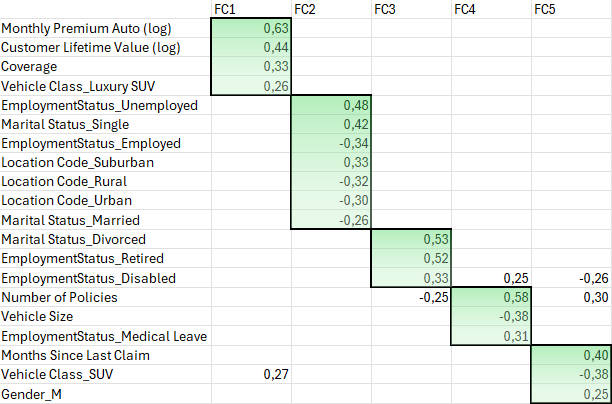


### 8. Diagnóstico post-FAMD: ortogonalidad garantizada

In [16]:
# --- Número de condición en el espacio FAMD ---
corr_famd   = np.corrcoef(X_reduced.T)
eigs_famd   = np.abs(np.linalg.eigvals(corr_famd))
cond_famd   = eigs_famd.max() / max(eigs_famd.min(), 1e-10)
det_famd    = np.linalg.det(corr_famd)

print("── Métricas de multicolinealidad: antes vs después ──\n")
comparison = pd.DataFrame({
    'Métrica':     ['Determinante', 'Número de condición'],
    'Preprocesado': [f'{det_raw:.2e}', f'{cond_raw:.1f}'],
    'FAMD':         [f'{det_famd:.6f}', f'{cond_famd:.2f}'],
    'Óptimo':       ['~1.0', '~1.0']
})
display(comparison)


── Métricas de multicolinealidad: antes vs después ──



,Métrica,Preprocesado,FAMD,Óptimo
0,Determinante,3.37e-80,1.000000,~1.0
1,Número de condición,126.0,1.00,~1.0


El espacio FAMD es perfectamente ortogonal por construcción del PCA.
Los factores tienen correlación 0 entre sí, una garantía de no-multicolinealidad

### 9. Interpretación actuarial de los factores

Las cargas muestran qué variables originales conforman cada factor. Esto permite asignarles una interpretación de riesgo.

In [17]:
# --- Top variables por factor (primeros 8) ---
n_show = min(8, N_FACTORS)
print("--- Top 3 variables por factor ──\n")
for fc in factor_names[:n_show]:
    top = loadings[fc].abs().sort_values(ascending=False).head(3)
    print(f"{fc}  [{pca_final.explained_variance_ratio_[factor_names.index(fc)]*100:.1f}% var.]")
    for feat, val in top.items():
        sign = '+' if loadings.loc[feat, fc] > 0 else '-'
        print(f"  {sign}{val:.3f}  {feat}")
    print()

--- Top 3 variables por factor ──

FC1  [10.1% var.]
  +0.627  Monthly Premium Auto (log)
  +0.440  Customer Lifetime Value (log)
  +0.327  Coverage

FC2  [7.6% var.]
  +0.479  EmploymentStatus_Unemployed
  +0.424  Marital Status_Single
  -0.338  EmploymentStatus_Employed

FC3  [5.2% var.]
  +0.534  Marital Status_Divorced
  +0.519  EmploymentStatus_Retired
  +0.335  EmploymentStatus_Disabled

FC4  [4.8% var.]
  +0.583  Number of Policies
  -0.383  Vehicle Size
  +0.313  EmploymentStatus_Medical Leave

FC5  [4.6% var.]
  +0.395  Months Since Last Claim
  -0.381  Vehicle Class_SUV
  +0.303  Number of Policies



Renombramos los 5 factores de acuerdo a las variables que tienen mayor carga:

| Factor | Nombre | 
|---|---|
| FC1 | Magnitud de Exposición |
| FC2 | Vulnerabilidad SocioCultural |
| FC3 | Situaciones Especiales |
| FC4 | Densidad en Cartera |
| FC5 | Severidad Latente |

### 10. Generación de artefactos para fases posteriores

| Artefacto | Contenido | Uso |
|---|---|---|
| `X_clustering.csv` | Factores FAMD + CLV (log) + Prima (log) | Segmentación con exposición financiera |
| `y_target.csv` | `Customer` + `Total Claim Amount` | Target limpio |
| `estratificadores.csv` | `Customer` + `State` + `Policy Type` | Análisis territorial |


In [18]:
# --- X clustering ---
df_famd.to_csv(f'{OUTPUT_DIR}X_famd_completo.csv', index=False)
print(f"X_famd_completo.csv     → {df_famd.shape}")


# --- Target ---
y.to_csv(f'{OUTPUT_DIR}y_target.csv', index=False)
print(f"y_target.csv            → {y.shape}")

# --- Estratificadores ---
estratificadores.to_csv(f'{OUTPUT_DIR}estratificadores.csv', index=False)
print(f"estratificadores.csv    → {estratificadores.shape}")

# --- Variables Codificadas ---
X_codificado.to_csv(f'{OUTPUT_DIR}preprocesado.csv', index=False)
print(f"preprocesado.csv    → {X_codificado.shape}")

X_famd_completo.csv     → (8971, 6)
y_target.csv            → (8971, 2)
estratificadores.csv    → (8971, 18)
preprocesado.csv    → (8971, 29)
